# Computer Vision Mini-Project
## Image Segmentation with Deep Learning and Prompting
## Owners: Ulkar Baghirova and Aytan Abdullayeva


# ============== ENVIRONMENT CHECK ======================


In [1]:
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

zsh:1: command not found: nvidia-smi


In [2]:
from psutil import virtual_memory
ram_gb = virtual_memory().total / 1e9
print('Your runtime has {:.1f} gigabytes of available RAM\n'.format(ram_gb))

if ram_gb < 20:
  print('Not using a high-RAM runtime')
else:
  print('You are using a high-RAM runtime!')

Your runtime has 17.2 gigabytes of available RAM

Not using a high-RAM runtime


# ==============IMPORTS ================

In [6]:
# =============================
# Warnings
# =============================
import warnings
warnings.filterwarnings("ignore")

# =============================
# General Purpose & OS
# =============================
import os
import shutil
import random
import tarfile
import csv
from pathlib import Path

# =============================
# Data Handling
# =============================
import numpy as np
import pandas as pd

# =============================
# Visualization
# =============================
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image

# =============================
# Scikit-learn Utilities
# =============================
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle

# =============================
# PyTorch & Deep Learning
# =============================
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, ConcatDataset
from torch.cuda.amp import autocast, GradScaler
from torchinfo import summary

# =============================
# Torchvision & Augmentations
# =============================
from torchvision import transforms
import albumentations as A

# =============================
# TensorFlow & Keras
# =============================
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# =============================
# Progress Bars
# =============================
from tqdm.auto import tqdm

# =============================
# Segmentation Models (SMP)
# =============================
import segmentation_models_pytorch as smp


# ================ DRIVE SETUP & LOG LOADING ==============

In [7]:
from google.colab import drive
drive.flush_and_unmount()  # Clean unmount
print(" Drive unmounted. Now remounting...")
drive.mount('/content/drive')

Drive not mounted, so nothing to flush and unmount.
 Drive unmounted. Now remounting...
Mounted at /content/drive


In [6]:
output_dir = "/content/drive/MyDrive/last/plots"
os.makedirs(output_dir, exist_ok=True)

# Loads training logs
log_unet = pd.read_csv("/content/drive/MyDrive/last/LastBestModelTrainingLog.csv")
log_auto = pd.read_csv("/content/drive/MyDrive/last/AutoEncoderPretrainedUnetTraining_log.csv")

# Loads test metrics
test_unet = pd.read_csv("/content/drive/MyDrive/last/test_metrics_Unet.csv")
test_auto = pd.read_csv("/content/drive/MyDrive/last/FinalAutotest_metrics_pretrained.csv")

# --- Plot 1: U-Net Training Metrics ---
plt.figure(figsize=(12, 6))
plt.plot(log_unet['Epoch'], log_unet['Train IoU'], label='Train IoU')
plt.plot(log_unet['Epoch'], log_unet['Val IoU'], label='Validation IoU')
plt.plot(log_unet['Epoch'], log_unet['Train Dice'], label='Train Dice')
plt.plot(log_unet['Epoch'], log_unet['Val Dice'], label='Validation Dice')
plt.plot(log_unet['Epoch'], log_unet['Train Acc'], label='Train Accuracy')
plt.plot(log_unet['Epoch'], log_unet['Val Acc'], label='Validation Accuracy')
plt.title('U-Net Training Metrics Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "unet_training_metrics.png"), dpi=300)
plt.close()

# --- Plot 2: Autoencoder Pretrained U-Net Metrics ---
plt.figure(figsize=(12, 6))
plt.plot(log_auto['Epoch'], log_auto['Train IoU'], label='Train IoU')
plt.plot(log_auto['Epoch'], log_auto['Val IoU'], label='Validation IoU')
plt.plot(log_auto['Epoch'], log_auto['Train Dice'], label='Train Dice')
plt.plot(log_auto['Epoch'], log_auto['Val Dice'], label='Validation Dice')
plt.plot(log_auto['Epoch'], log_auto['Train Acc'], label='Train Accuracy')
plt.plot(log_auto['Epoch'], log_auto['Val Acc'], label='Validation Accuracy')
plt.title('Autoencoder-Pretrained U-Net Training Metrics Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "autoencoder_unet_training_metrics.png"), dpi=300)
plt.close()

# --- Plot 3: Test Metrics Bar Plot ---
test_df = pd.DataFrame({
    "Model": ["U-Net", "Autoencoder Pretrained"],
    "IoU": [test_unet["IoU"].values[0], test_auto["IoU"].values[0]],
    "Dice": [test_unet["Dice"].values[0], test_auto["Dice"].values[0]],
    "Accuracy": [test_unet["Accuracy"].values[0], test_auto["Accuracy"].values[0]],
})

test_df_melted = test_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(10, 6))
sns.barplot(data=test_df_melted, x="Metric", y="Score", hue="Model")
plt.title("Test Performance Comparison")
plt.ylabel("Score")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "test_comparison_metrics.png"), dpi=300)
plt.close()

print(" All plots saved to:", output_dir)


 All plots saved to: /content/drive/MyDrive/last/plots


# =================== DATASET EXTRACTION =======================


In [ ]:
#Setup paths
TAR_PATH = "/content/drive/MyDrive/Dataset_filtered.tar"
NEW_FOLDER_NAME = "CleanExtractedDataset"
EXTRACT_PATH = f"/content/drive/MyDrive/{NEW_FOLDER_NAME}"

#Forces delete the folder if it exists
if os.path.exists(EXTRACT_PATH):
    print(" Old folder exists. Deleting it...")
    shutil.rmtree(EXTRACT_PATH)
    print(" Old folder deleted.")

# Creates new folder and extract
os.makedirs(EXTRACT_PATH, exist_ok=True)

with tarfile.open(TAR_PATH, "r") as tar:
    tar.extractall(path=EXTRACT_PATH)
    print(f"\n Extracted tar into: {EXTRACT_PATH}")

# Prints structure to confirm
print("\nFolder structure:")
for root, dirs, files in os.walk(EXTRACT_PATH):
    print(f"{root}")
    for d in dirs:
        print(f"   {d}")
    for f in files[:5]:
        print(f"   {f}")


In [ ]:
EXTRACT_PATH = "/content/drive/MyDrive/CleanExtractedDataset/Dataset_filtered"

TRAINVAL_IMAGES_PATH = os.path.join(EXTRACT_PATH, "TrainVal/color")
TRAINVAL_MASKS_PATH = os.path.join(EXTRACT_PATH, "TrainVal/label")

trainval_images_filenames = sorted(os.listdir(TRAINVAL_IMAGES_PATH))
trainval_masks_filenames = sorted(os.listdir(TRAINVAL_MASKS_PATH))

image_mask_pairs = [
    (img, img.replace(".jpg", ".png"))
    for img in trainval_images_filenames
    if img.replace(".jpg", ".png") in trainval_masks_filenames
]

# ================= DATASET SPLITTING ===============

In [ ]:
# Defines paths
EXTRACT_PATH = "/content/drive/MyDrive/CleanExtractedDataset/Dataset_filtered"

TRAINVAL_IMAGES_PATH = os.path.join(EXTRACT_PATH, "TrainVal/color")
TRAINVAL_MASKS_PATH = os.path.join(EXTRACT_PATH, "TrainVal/label")

TRAIN_IMAGES_PATH = os.path.join(EXTRACT_PATH, "Train/color")
TRAIN_MASKS_PATH = os.path.join(EXTRACT_PATH, "Train/label")
VAL_IMAGES_PATH = os.path.join(EXTRACT_PATH, "Validation/color")
VAL_MASKS_PATH = os.path.join(EXTRACT_PATH, "Validation/label")


# Creates destination folders
os.makedirs(TRAIN_IMAGES_PATH, exist_ok=True)
os.makedirs(TRAIN_MASKS_PATH, exist_ok=True)
os.makedirs(VAL_IMAGES_PATH, exist_ok=True)
os.makedirs(VAL_MASKS_PATH, exist_ok=True)

# Matchs images and masks
trainval_images_filenames = sorted(os.listdir(TRAINVAL_IMAGES_PATH))
trainval_masks_filenames = sorted(os.listdir(TRAINVAL_MASKS_PATH))

image_mask_pairs = [
    (img, img.replace(".jpg", ".png"))
    for img in trainval_images_filenames
    if img.replace(".jpg", ".png") in trainval_masks_filenames
]

train_pairs, val_pairs = train_test_split(image_mask_pairs, test_size=0.2, random_state=42)

# Moves function
def move_files(pairs, src_img_path, src_mask_path, dst_img_path, dst_mask_path):
    for img_name, mask_name in pairs:
        shutil.move(os.path.join(src_img_path, img_name), os.path.join(dst_img_path, img_name))
        shutil.move(os.path.join(src_mask_path, mask_name), os.path.join(dst_mask_path, mask_name))

# Moves files
move_files(train_pairs, TRAINVAL_IMAGES_PATH, TRAINVAL_MASKS_PATH, TRAIN_IMAGES_PATH, TRAIN_MASKS_PATH)
move_files(val_pairs, TRAINVAL_IMAGES_PATH, TRAINVAL_MASKS_PATH, VAL_IMAGES_PATH, VAL_MASKS_PATH)

print("Dataset split complete!")
print(f"Training images: {len(train_pairs)}")
print(f"Validation images: {len(val_pairs)}")


In [ ]:
TEST_IMAGES_PATH = os.path.join(EXTRACT_PATH, "Test/color")
TEST_MASKS_PATH = os.path.join(EXTRACT_PATH, "Test/label")

In [ ]:
print("Train Images:", len(os.listdir(TRAIN_IMAGES_PATH)))
print("Train Masks:", len(os.listdir(TRAIN_MASKS_PATH)))
print("Validation Images:", len(os.listdir(VAL_IMAGES_PATH)))
print("Validation Masks:", len(os.listdir(VAL_MASKS_PATH)))
print("Test Images:", len(os.listdir(TEST_IMAGES_PATH)))
print("Test Masks:", len(os.listdir(TEST_MASKS_PATH)))

# =============== TRAIN/VAL SAMPLE VISUALISATION ================

In [ ]:
# Function to load an image
def load_image(image_path):
    image = cv2.imread(image_path)
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB) if image is not None else None

# Function to load a mask
def load_mask(mask_path):
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    return mask if mask is not None else None

# Function to show image and its corresponding mask
def show_image_mask(image_path, mask_path):
    image = load_image(image_path)
    mask = load_mask(mask_path)

    if image is None or mask is None:
        print(f"Skipping: {image_path} or {mask_path} not found")
        return

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.axis('off')
    plt.title("Image")

    plt.subplot(1, 2, 2)
    plt.imshow(mask, cmap='gray')
    plt.axis('off')
    plt.title("Mask")

    plt.show()

In [ ]:
def show_image_mask(img_path, mask_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Image")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(mask, cmap='jet')
    plt.title("Mask")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

train_pairs = list(zip(
    sorted(os.listdir(TRAIN_IMAGES_PATH)),
    sorted(os.listdir(TRAIN_MASKS_PATH))
))
train_pairs = shuffle(train_pairs, random_state=42)

val_pairs = list(zip(
    sorted(os.listdir(VAL_IMAGES_PATH)),
    sorted(os.listdir(VAL_MASKS_PATH))
))
val_pairs = shuffle(val_pairs, random_state=42)

# Show matching pairs
print("\n🔹 Training Samples")
for i in range(5):
    show_image_mask(
        os.path.join(TRAIN_IMAGES_PATH, train_pairs[i][0]),
        os.path.join(TRAIN_MASKS_PATH, train_pairs[i][1])
    )

print("\n🔹 Validation Samples")
for i in range(5):
    show_image_mask(
        os.path.join(VAL_IMAGES_PATH, val_pairs[i][0]),
        os.path.join(VAL_MASKS_PATH, val_pairs[i][1])
    )


# =================== IMAGE SIZE STATISTICS =================


In [ ]:
# Function to get image sizes
def get_image_sizes(image_dir):
    sizes = []
    for image_file in os.listdir(image_dir):
        image_path = os.path.join(image_dir, image_file)
        image = cv2.imread(image_path)
        if image is not None:
            sizes.append(image.shape[:2])
    return sizes

# Function to print top 10 unique image sizes and their counts
def print_top_image_sizes(image_sizes):
    unique_sizes, counts = np.unique(image_sizes, axis=0, return_counts=True)
    sorted_indices = np.argsort(-counts)
    print("\nTop 10 Image Sizes:")
    for i in sorted_indices[:10]:  # Show only top 10
        print(f"Size: {unique_sizes[i]}, Count: {counts[i]}")

# Get and print top 10 image size statistics
train_image_sizes = get_image_sizes(TRAIN_IMAGES_PATH)
val_image_sizes = get_image_sizes(VAL_IMAGES_PATH)

print("\nTraining Set Image Sizes:")
print_top_image_sizes(train_image_sizes)
print("\nValidation Set Image Sizes:")
print_top_image_sizes(val_image_sizes)

# =================== RESIZING IMAGES =====================


In [ ]:
# Define target resize dimensions
TARGET_WIDTH = 256
TARGET_HEIGHT = 256

def resize_image(image, target_width, target_height):
    return cv2.resize(image, (target_width, target_height), interpolation=cv2.INTER_AREA)

# Function to resize and save images in a directory
def resize_and_save_images(input_dir, output_dir, target_width, target_height):
    if not os.path.exists(output_dir):
        os.makedirs(output_dir, exist_ok=True)

    for filename in os.listdir(input_dir):
        image_path = os.path.join(input_dir, filename)
        image = cv2.imread(image_path)

        if image is not None:
            resized_image = resize_image(image, target_width, target_height)
            output_path = os.path.join(output_dir, filename)
            cv2.imwrite(output_path, resized_image)
        else:
            print(f"Skipping {filename}, could not read image.")

# Define output directories for resized images
RESIZED_TRAIN_IMAGES_PATH = "/content/drive/MyDrive/CleanExtractedDataset/Dataset_filtered/Resized_Train/color"
RESIZED_TRAIN_MASKS_PATH = "/content/drive/MyDrive/CleanExtractedDataset/Dataset_filtered/Resized_Train/label"

RESIZED_VAL_IMAGES_PATH = "/content/drive/MyDrive/CleanExtractedDataset/Dataset_filtered/Resized_Validation/color"
RESIZED_VAL_MASKS_PATH = "/content/drive/MyDrive/CleanExtractedDataset/Dataset_filtered/Resized_Validation/label"

RESIZED_TEST_IMAGES_PATH = "/content/drive/MyDrive/CleanExtractedDataset/Dataset_filtered/Resized_Test/color"
RESIZED_TEST_MASKS_PATH = "/content/drive/MyDrive/CleanExtractedDataset/Dataset_filtered/Resized_Test/label"


# Resize training, validation, and test images
resize_and_save_images(TRAIN_IMAGES_PATH, RESIZED_TRAIN_IMAGES_PATH, TARGET_WIDTH, TARGET_HEIGHT)
resize_and_save_images(TRAIN_MASKS_PATH, RESIZED_TRAIN_MASKS_PATH, TARGET_WIDTH, TARGET_HEIGHT)
resize_and_save_images(VAL_IMAGES_PATH, RESIZED_VAL_IMAGES_PATH, TARGET_WIDTH, TARGET_HEIGHT)
resize_and_save_images(VAL_MASKS_PATH, RESIZED_VAL_MASKS_PATH, TARGET_WIDTH, TARGET_HEIGHT)
resize_and_save_images(TEST_IMAGES_PATH, RESIZED_TEST_IMAGES_PATH, TARGET_WIDTH, TARGET_HEIGHT)
resize_and_save_images(TEST_MASKS_PATH, RESIZED_TEST_MASKS_PATH, TARGET_WIDTH, TARGET_HEIGHT)

print("\nResizing complete! Images saved in Resized_Train, Resized_Validation, and Resized_Test folders.")

print("\nResizing complete! Images saved in Resized_Train and Resized_Validation folders.")

In [ ]:
# Define output directories for resized images
RESIZED_TRAIN_IMAGES_PATH = "/content/drive/MyDrive/CleanExtractedDataset/Dataset_filtered/Resized_Train/color"
RESIZED_TRAIN_MASKS_PATH = "/content/drive/MyDrive/CleanExtractedDataset/Dataset_filtered/Resized_Train/label"

RESIZED_VAL_IMAGES_PATH = "/content/drive/MyDrive/CleanExtractedDataset/Dataset_filtered/Resized_Validation/color"
RESIZED_VAL_MASKS_PATH = "/content/drive/MyDrive/CleanExtractedDataset/Dataset_filtered/Resized_Validation/label"

RESIZED_TEST_IMAGES_PATH = "/content/drive/MyDrive/CleanExtractedDataset/Dataset_filtered/Resized_Test/color"
RESIZED_TEST_MASKS_PATH = "/content/drive/MyDrive/CleanExtractedDataset/Dataset_filtered/Resized_Test/label"
# Function to display a few resized images and masks
def show_sample_resized_images(image_dir, mask_dir, num_samples=5):
    image_filenames = sorted(os.listdir(image_dir))
    mask_filenames = sorted(os.listdir(mask_dir))

    if len(image_filenames) == 0 or len(mask_filenames) == 0:
        print("No resized images found.")
        return

    plt.figure(figsize=(12, num_samples * 3))
    for i in range(min(num_samples, len(image_filenames))):
        image_path = os.path.join(image_dir, image_filenames[i])
        mask_path = os.path.join(mask_dir, mask_filenames[i])

        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        plt.subplot(num_samples, 2, 2 * i + 1)
        plt.imshow(image)
        plt.axis('off')
        plt.title("Resized Image")

        plt.subplot(num_samples, 2, 2 * i + 2)
        plt.imshow(mask, cmap='gray')
        plt.axis('off')
        plt.title("Resized Mask")

    plt.tight_layout()
    plt.show()

# Display sample resized images and masks
show_sample_resized_images(RESIZED_TRAIN_IMAGES_PATH, RESIZED_TRAIN_MASKS_PATH)

# ================== AUGMENTATION SETUP ====================


In [ ]:
# ============================
# AUGMENTATION SETUP
# ============================
strong_augmentation = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.RandomRotate90(p=0.3),
    A.ShiftScaleRotate(shift_limit=0.02, scale_limit=0.02, rotate_limit=8, p=0.3),
    A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.1),
    A.GaussianBlur(blur_limit=(3, 3), p=0.1),
    A.HueSaturationValue(hue_shift_limit=5, sat_shift_limit=10, val_shift_limit=5, p=0.1),
    A.Resize(256, 256),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
])

In [ ]:
# ============================
# AUGMENTATION FUNCTION
# ============================
AUG_BASE_PATH = "/content/drive/MyDrive/CleanExtractedDataset/Dataset_filtered/Augmented_Train"
AUG_TRAIN_IMAGES_PATH = os.path.join(AUG_BASE_PATH, "color")
AUG_TRAIN_MASKS_PATH = os.path.join(AUG_BASE_PATH, "label")

os.makedirs(AUG_TRAIN_IMAGES_PATH, exist_ok=True)
os.makedirs(AUG_TRAIN_MASKS_PATH, exist_ok=True)

RESIZED_TRAIN_IMAGES_PATH = "/content/drive/MyDrive/CleanExtractedDataset/Dataset_filtered/Resized_Train/color"
RESIZED_TRAIN_MASKS_PATH = "/content/drive/MyDrive/CleanExtractedDataset/Dataset_filtered/Resized_Train/label"

def augment_and_save_images(input_dir, mask_dir, output_dir, output_mask_dir, num_augments=3):
    image_filenames = sorted(os.listdir(input_dir))
    mask_filenames = sorted(os.listdir(mask_dir))

    for image_filename, mask_filename in zip(image_filenames, mask_filenames):
        image_path = os.path.join(input_dir, image_filename)
        mask_path = os.path.join(mask_dir, mask_filename)

        image = cv2.imread(image_path)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        if image is not None and mask is not None:
            for i in range(num_augments):
                augmented = strong_augmentation(image=image, mask=mask)
                aug_image = augmented['image']
                aug_mask = augmented['mask']

                #  Convert image back to uint8 before saving
                aug_image_uint8 = np.clip(aug_image * 255.0, 0, 255).astype(np.uint8)

                aug_image_filename = f"aug_{i}_{image_filename}"
                aug_mask_filename = f"aug_{i}_{mask_filename}"

                cv2.imwrite(os.path.join(output_dir, aug_image_filename), aug_image_uint8)
                cv2.imwrite(os.path.join(output_mask_dir, aug_mask_filename), aug_mask)
        else:
            print(f"Skipping {image_filename} or {mask_filename}, could not read.")


augment_and_save_images(
    RESIZED_TRAIN_IMAGES_PATH,
    RESIZED_TRAIN_MASKS_PATH,
    AUG_TRAIN_IMAGES_PATH,
    AUG_TRAIN_MASKS_PATH
)

print("\nData augmentation complete! Augmented images saved in Augmented_Train folder.")

# =============== AUGMENTED SAMPLE VISUALISATION =================

In [ ]:
# ============================
# DATASET VISUALISATION
# ============================
def show_augmented_samples(image_dir, mask_dir, num_samples=5):
    image_filenames = sorted(os.listdir(image_dir))[:num_samples]
    mask_filenames = sorted(os.listdir(mask_dir))[:num_samples]

    for img_file, mask_file in zip(image_filenames, mask_filenames):
        img_path = os.path.join(image_dir, img_file)
        mask_path = os.path.join(mask_dir, mask_file)

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        plt.figure(figsize=(10, 4))
        plt.subplot(1, 2, 1)
        plt.imshow(image)
        plt.title(f"Augmented Image: {img_file}")
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.imshow(mask, cmap='jet')
        plt.title(f"Augmented Mask: {mask_file}")
        plt.axis('off')

        plt.tight_layout()
        plt.show()

show_augmented_samples(AUG_TRAIN_IMAGES_PATH, AUG_TRAIN_MASKS_PATH, num_samples=5)


# ================= CLASS REMAPPING AND CHECKS ==================

In [ ]:
import os
import numpy as np
import cv2
from collections import defaultdict

AUG_MASKS_PATH = "/content/drive/MyDrive/CleanExtractedDataset/Dataset_filtered/Augmented_Train/label"

def get_class_pixel_counts(mask_dir):
    pixel_counts = defaultdict(int)

    for mask_name in sorted(os.listdir(mask_dir)):
        if mask_name.endswith(".png"):
            mask_path = os.path.join(mask_dir, mask_name)
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

            if mask is not None:
                unique, counts = np.unique(mask, return_counts=True)
                for label, count in zip(unique, counts):
                    pixel_counts[label] += count
            else:
                print(f" Could not load mask: {mask_name}")

    return dict(sorted(pixel_counts.items()))

# Run the count
class_pixel_counts = get_class_pixel_counts(AUG_MASKS_PATH)

# Print the results
print("Pixel counts per class label in augmented masks:")
for label, count in class_pixel_counts.items():
    print(f"  Label {label}: {count:,} pixels")



Pixel counts per class label in augmented masks:
  Label 0: 336,016,934 pixels
  Label 1: 58,385 pixels
  Label 2: 62,379 pixels
  Label 3: 51,997 pixels
  Label 4: 50,611 pixels
  Label 5: 43,471 pixels
  Label 6: 65,043 pixels
  Label 7: 40,766 pixels
  Label 8: 47,660 pixels
  Label 9: 37,089 pixels
  Label 10: 51,014 pixels
  Label 11: 34,381 pixels
  Label 12: 41,558 pixels
  Label 13: 31,108 pixels
  Label 14: 45,424 pixels
  Label 15: 31,518 pixels
  Label 16: 40,661 pixels
  Label 17: 32,029 pixels
  Label 18: 39,151 pixels
  Label 19: 27,452 pixels
  Label 20: 48,040 pixels
  Label 21: 26,982 pixels
  Label 22: 40,284 pixels
  Label 23: 25,107 pixels
  Label 24: 36,485 pixels
  Label 25: 27,255 pixels
  Label 26: 24,812 pixels
  Label 27: 42,200 pixels
  Label 28: 28,018 pixels
  Label 29: 32,004 pixels
  Label 30: 26,157 pixels
  Label 31: 37,638 pixels
  Label 32: 23,052 pixels
  Label 33: 36,968 pixels
  Label 34: 26,916 pixels
  Label 35: 54,158 pixels
  Label 36: 24,741 p

In [ ]:
# Find masks that contain 255 but NOT 38
def find_masks_with_255_no_38(mask_dir):
    for fname in sorted(os.listdir(mask_dir)):
        if fname.endswith(".png"):
            path = os.path.join(mask_dir, fname)
            mask = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
            if mask is not None:
                labels = np.unique(mask)
                if 255 in labels and 38 not in labels:
                    return path
    return None

mask_with_255_no_38 = find_masks_with_255_no_38(AUG_MASKS_PATH)
print("Check this mask:", mask_with_255_no_38)


Check this mask: /content/drive/MyDrive/CleanExtractedDataset/Dataset_filtered/Augmented_Train/label/aug_0_american_bulldog_100.png


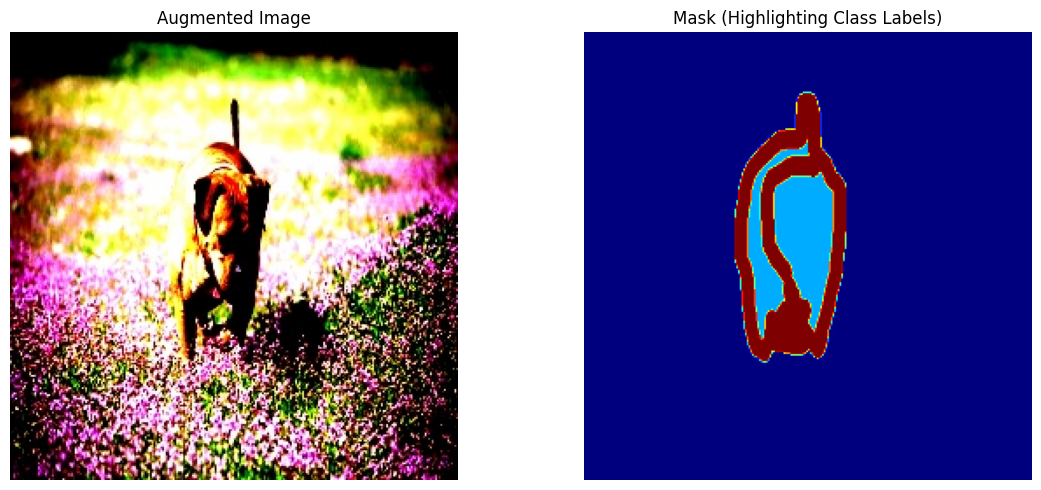

In [ ]:
image_path = "/content/drive/MyDrive/CleanExtractedDataset/Dataset_filtered/Augmented_Train/color/aug_0_american_bulldog_100.jpg"
mask_path = "/content/drive/MyDrive/CleanExtractedDataset/Dataset_filtered/Augmented_Train/label/aug_0_american_bulldog_100.png"

from matplotlib import pyplot as plt
import cv2

def show_image_and_mask(image_path, mask_path):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.title("Augmented Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(mask, cmap="jet")
    plt.title("Mask (Highlighting Class Labels)")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

show_image_and_mask(image_path, mask_path)

In [ ]:
def debug_mask_classes(mask_dir, image_dir, class_id=38):
    for fname in sorted(os.listdir(mask_dir)):
        mask_path = os.path.join(mask_dir, fname)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask is not None and class_id in np.unique(mask):
            print(" Found class", class_id, "in:", fname)
            img_path = os.path.join(image_dir, fname.replace(".png", ".jpg"))
            image = cv2.imread(img_path)
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

            plt.figure(figsize=(10, 4))
            plt.subplot(1, 2, 1)
            plt.imshow(image)
            plt.title("Image")
            plt.axis('off')

            plt.subplot(1, 2, 2)
            plt.imshow(mask, cmap='jet')
            plt.title(f"Mask (with class {class_id})")
            plt.axis('off')
            plt.show()
            break  # show only one for now


 Found class 38 in: aug_0_Abyssinian_10.png


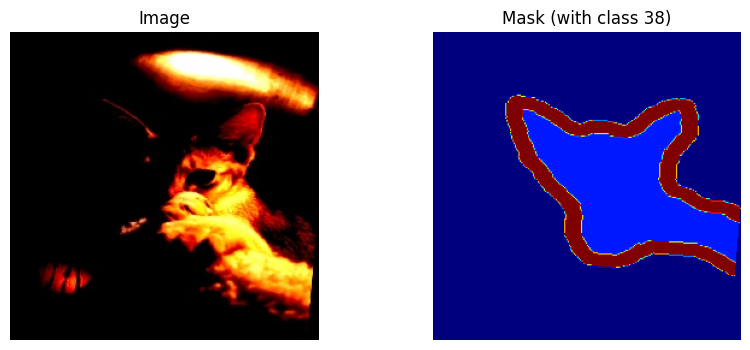

In [ ]:
debug_mask_classes(AUG_MASKS_PATH, AUG_IMAGES_PATH, class_id=38)

# ==== MODEL COMPONENTS (CBAM, Attention Block) ===

In [14]:
import albumentations as A

# ============================
# CLASS SETUP
# ============================
CLASS_LABELS = [0, 38, 75]  # background, cat, dog
CLASS_TO_IDX = {0: 0, 38: 1, 75: 2}
IDX_TO_CLASS = {0: 0, 1: 38, 2: 75}
NUM_CLASSES = len(CLASS_LABELS)

# Optional: Custom class weights to handle imbalance
import torch
CLASS_WEIGHTS = torch.tensor([1.0, 6.0, 3.0] , device=torch.device("cuda" if torch.cuda.is_available() else "cpu"))

# ============================
# SHARED TRANSFORM DEFINITION
# ============================
shared_transform = A.Compose([
    A.Resize(256, 256),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.ShiftScaleRotate(shift_limit=0.0625, scale_limit=0.2, rotate_limit=20, p=0.4),
    A.ElasticTransform(p=0.2),
    A.GridDistortion(p=0.2),
    A.CLAHE(p=0.3),  # Improve contrast for low-visibility regions
    A.Normalize(),
])

# ============================
# MASK REMAPPING FUNCTION
# ============================
def remap_mask(mask):
    mask = np.where(mask == 255, 0, mask)  # Treat contour as background
    remapped_mask = np.zeros_like(mask)
    for orig_class, idx in CLASS_TO_IDX.items():
        remapped_mask[mask == orig_class] = idx
    return remapped_mask

# ============================
# FOCAL + TVERSKY LOSS
# ============================
class FocalTverskyLoss(nn.Module):
    def __init__(self, alpha=0.6, beta=0.4, gamma=1.33, smooth=1e-6):
        super().__init__()
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma
        self.smooth = smooth

    def forward(self, pred, target):
        pred = torch.softmax(pred, dim=1)
        target_one_hot = F.one_hot(target, num_classes=pred.shape[1]).permute(0, 3, 1, 2).float()
        TP = (pred * target_one_hot).sum(dim=(2, 3))
        FP = ((1 - target_one_hot) * pred).sum(dim=(2, 3))
        FN = (target_one_hot * (1 - pred)).sum(dim=(2, 3))
        tversky = (TP + self.smooth) / (TP + self.alpha * FP + self.beta * FN + self.smooth)
        focal_tversky = torch.pow((1 - tversky), self.gamma)
        return focal_tversky.mean()


def combined_loss(pred, target):
    ce = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS)(pred, target)
    focal_tv = FocalTverskyLoss(alpha=0.6, beta=0.4, gamma=1.33)(pred, target)
    return ce + focal_tv

# ============================
# DATASET CLASS
# ============================
class SegDataset(Dataset):
    def __init__(self, img_dir, mask_dir, transform=None):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.images = sorted(os.listdir(img_dir))
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        mask_name = img_name.replace(".jpg", ".png")
        image = cv2.imread(os.path.join(self.img_dir, img_name))
        mask = cv2.imread(os.path.join(self.mask_dir, mask_name), cv2.IMREAD_GRAYSCALE)

        if image is None or mask is None:
            raise ValueError(f"Error loading image or mask at index {idx}: {img_name}")

        mask = remap_mask(mask)
        augmented = self.transform(image=image, mask=mask)
        img = torch.tensor(augmented['image'].transpose(2, 0, 1), dtype=torch.float32)
        mask = torch.tensor(augmented['mask'], dtype=torch.long)

        return img, mask


In [16]:
# ============================
# CBAM MODULE
# ============================

class CBAM(nn.Module):
    """
    Convolutional Block Attention Module (CBAM)

    This module applies sequential channel and spatial attention to enhance
    feature representations. It improves the model's ability to focus on
    informative regions by first computing channel attention via global
    average and max pooling, followed by spatial attention using a
    convolution over concatenated channel-wise descriptors.

    Args:
        channels (int): Number of input feature channels.
        reduction (int): Reduction ratio for the channel attention MLP.

    Returns:
        Tensor: Attention-refined feature map with the same shape as input.
    """
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)

        self.mlp = nn.Sequential(
            nn.Conv2d(channels, channels // reduction, 1, bias=False),
            nn.ReLU(),
            nn.Conv2d(channels // reduction, channels, 1, bias=False)
        )

        self.sigmoid_channel = nn.Sigmoid()
        self.conv_spatial = nn.Conv2d(2, 1, kernel_size=7, padding=3, bias=False)
        self.sigmoid_spatial = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.mlp(self.avg_pool(x))
        max_out = self.mlp(self.max_pool(x))
        channel_att = self.sigmoid_channel(avg_out + max_out)
        x = x * channel_att

        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        spatial_att = self.sigmoid_spatial(self.conv_spatial(torch.cat([avg_out, max_out], dim=1)))
        x = x * spatial_att

        return x


In [17]:
# ============================
# ATTENTION BLOCK
# ============================

class AttentionBlock(nn.Module):
    """
    Attention Block with CBAM

    This block computes attention between the gating signal (from the decoder)
    and the encoder features to selectively highlight relevant regions. It applies
    additive attention to align feature maps, followed by a sigmoid-based gating.
    Additionally, CBAM is applied to further refine the attended features.

    Args:
        F_g (int): Number of channels in the gating signal (decoder).
        F_l (int): Number of channels in the encoder feature map.
        F_int (int): Intermediate number of channels for computing attention.

    Returns:
        Tensor: Refined encoder feature map after applying attention and CBAM.
    """
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1),
            nn.BatchNorm2d(F_int)
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1),
            nn.BatchNorm2d(F_int)
        )
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        self.cbam = CBAM(F_l)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        x = x * psi
        x = self.cbam(x)
        return x


# ================ ATTENTION U-NET MODEL ================

In [18]:
# ============================
# ATTENTION U-NET MODEL
# ============================

class AttentionUNet(nn.Module):
    """
    Attention U-Net with CBAM Modules

    This model extends the traditional U-Net architecture by integrating CBAM
    (Convolutional Block Attention Modules) and attention gates between encoder
    and decoder paths. CBAM enhances spatial and channel-wise attention within
    convolutional blocks, while attention gates refine skip connections,
    ensuring that only relevant features from the encoder are propagated to
    the decoder.

    Architecture:
        - Encoder: Four downsampling blocks with CBAM, extracting features at increasing depth.
        - Bottleneck: Deepest layer with highest channel capacity (1024).
        - Decoder: Four upsampling blocks with attention gates and skip connections.
        - Output: Final segmentation mask using 1×1 convolution.

    Args:
        in_channels (int): Number of input image channels (default: 3 for RGB).
        out_channels (int): Number of output classes for segmentation.

    Returns:
        Tensor: Segmentation map with shape [B, out_channels, H, W].
    """
    def __init__(self, in_channels=3, out_channels=NUM_CLASSES):
        super().__init__()
        def block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(),
                nn.Conv2d(out_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(),
                CBAM(out_c)
            )

        self.enc1 = block(in_channels, 64)
        self.enc2 = block(64, 128)
        self.enc3 = block(128, 256)
        self.enc4 = block(256, 512)
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = block(512, 1024)

        self.att4 = AttentionBlock(512, 512, 256)
        self.up4 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.dec4 = block(1024, 512)

        self.att3 = AttentionBlock(256, 256, 128)
        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = block(512, 256)

        self.att2 = AttentionBlock(128, 128, 64)
        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = block(256, 128)

        self.att1 = AttentionBlock(64, 64, 32)
        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = block(128, 64)

        self.out = nn.Conv2d(64, out_channels, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b = self.bottleneck(self.pool(e4))

        g4 = self.up4(b)
        x4 = self.att4(g4, e4)
        d4 = self.dec4(torch.cat([g4, x4], dim=1))

        g3 = self.up3(d4)
        x3 = self.att3(g3, e3)
        d3 = self.dec3(torch.cat([g3, x3], dim=1))

        g2 = self.up2(d3)
        x2 = self.att2(g2, e2)
        d2 = self.dec2(torch.cat([g2, x2], dim=1))

        g1 = self.up1(d2)
        x1 = self.att1(g1, e1)
        d1 = self.dec1(torch.cat([g1, x1], dim=1))

        return self.out(d1)


# ============ METRIC EVALUATION & TRAINING LOOP ==============


In [30]:
# ============================
# METRIC EVALUATION
# ============================

def evaluate_metrics(model, loader):
    """
    Computes per-class and overall segmentation metrics: IoU, Dice score, and Accuracy.

    This function evaluates a trained segmentation model using a given dataloader.
    It computes intersection-over-union (IoU), Dice score, and pixel-wise accuracy
    for each class, and returns their mean values. It also prints the per-class metrics.

    Args:
        model (torch.nn.Module): The trained segmentation model.
        loader (DataLoader): DataLoader containing image-mask pairs to evaluate.

    Returns:
        tuple:
            - mean IoU (float)
            - mean Dice score (float)
            - mean pixel accuracy (float)
    """
    model.eval()
    num_classes = model.out.out_channels
    iou_per_class = torch.zeros(num_classes)
    dice_per_class = torch.zeros(num_classes)
    acc_per_class = torch.zeros(num_classes)
    class_counts = torch.zeros(num_classes)

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            preds = torch.argmax(out, dim=1)
            for cls in range(num_classes):
                p_cls = (preds == cls)
                t_cls = (y == cls)
                intersection = (p_cls & t_cls).sum()
                union = (p_cls | t_cls).sum()
                dice = (2 * intersection) / ((p_cls.sum() + t_cls.sum()) + 1e-8)
                acc = (p_cls == t_cls).float().mean()
                if t_cls.sum() > 0:
                    iou_per_class[cls] += (intersection.float() / (union.float() + 1e-8)).cpu()
                    dice_per_class[cls] += dice.cpu()
                    acc_per_class[cls] += acc.cpu()
                    class_counts[cls] += 1

    iou_mean = (iou_per_class / class_counts.clamp(min=1)).numpy()
    dice_mean = (dice_per_class / class_counts.clamp(min=1)).numpy()
    acc_mean = (acc_per_class / class_counts.clamp(min=1)).numpy()

    print("--- Per-Class Metrics (Filtered Classes Only) ---")
    for cls in range(num_classes):
        real_class = IDX_TO_CLASS[cls]
        print(f"Class {real_class}: IoU={iou_mean[cls]:.4f}, Dice={dice_mean[cls]:.4f}, Acc={acc_mean[cls]:.4f}")

    return iou_mean.mean(), dice_mean.mean(), acc_mean.mean()


In [19]:
# ============================
# TRAINING LOOP
# ============================

def train(model, train_loader, val_loader, epochs=75, log_path="/content/drive/MyDrive/CleanExtractedDataset/LastBestModelTrainingLog.csv"):
    """
    Trains a segmentation model using a mixed-precision training loop with
    early stopping, learning rate scheduling, and metric logging.

    This function runs the training and validation phases over multiple epochs.
    It logs performance metrics (IoU, Dice, Accuracy) to a CSV file, saves the
    best model based on validation Dice score, and generates a plot of IoU over epochs.

    Args:
        model (torch.nn.Module): The segmentation model to train.
        train_loader (DataLoader): DataLoader containing the training dataset.
        val_loader (DataLoader): DataLoader containing the validation dataset.
        epochs (int, optional): Number of training epochs (default: 75).
        log_path (str, optional): Path to save the training log CSV.

    Behavior:
        - Uses AdamW optimizer with learning rate scheduling.
        - Applies automatic mixed-precision (AMP) training via GradScaler.
        - Implements early stopping based on validation Dice score.
        - Saves best-performing model to "BestModelUnet.pth".
        - Outputs training progress and final IoU plot.

    Returns:
        None
    """
    os.makedirs(os.path.dirname(log_path), exist_ok=True)
    if not os.path.exists(log_path):
        with open(log_path, mode='w', newline='') as f:
            writer = csv.writer(f)
            writer.writerow(["Epoch", "Loss", "Train IoU", "Train Dice", "Train Acc", "Val IoU", "Val Dice", "Val Acc"])

    losses, train_ious, val_ious = [], [], []
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2)
    scaler = GradScaler()

    best_val_dice = 0
    patience = 5
    no_improve_epochs = 0

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for x, y in tqdm(train_loader):
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            with autocast():
                pred = model(x)
                loss = combined_loss(pred, y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            total_loss += loss.item()

        val_iou, val_dice, val_acc = evaluate_metrics(model, val_loader)
        train_iou, train_dice, train_acc = evaluate_metrics(model, train_loader)
        print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")
        print(f"Train IoU: {train_iou:.4f}, Dice: {train_dice:.4f}, Acc: {train_acc:.4f}")
        print(f" Val IoU: {val_iou:.4f}, Dice: {val_dice:.4f}, Acc: {val_acc:.4f}")

        scheduler.step(total_loss)

        if val_dice > best_val_dice:
            best_val_dice = val_dice
            no_improve_epochs = 0
            torch.save(model.state_dict(), "BestModelUnet.pth")
        else:
            no_improve_epochs += 1
            if no_improve_epochs >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

        losses.append(total_loss / len(train_loader))
        train_ious.append(train_iou)
        val_ious.append(val_iou)

        with open(log_path, mode='a', newline='') as f:
            writer = csv.writer(f)
            writer.writerow([
                epoch + 1,
                round(total_loss / len(train_loader), 4),
                round(train_iou, 4), round(train_dice, 4), round(train_acc, 4),
                round(val_iou, 4), round(val_dice, 4), round(val_acc, 4)
            ])

    # Plot IoU over epochs
    plt.figure(figsize=(8,5))
    plt.plot(train_ious, label='Train IoU')
    plt.plot(val_ious, label='Val IoU')
    plt.xlabel("Epoch")
    plt.ylabel("IoU")
    plt.title("IoU over Epochs")
    plt.legend()
    plt.grid(True)
    plt.savefig("iou_over_epochs.png")
    plt.show()


# ============================
# EVALUATION VISUALISATION
# ============================

In [29]:
def evaluate_and_visualise(model, loader):
    """
    Evaluates the model on a random batch and visualises predictions.

    This function selects a random batch from the provided dataloader,
    passes it through the model in evaluation mode, and visualises the
    input image, ground truth mask, and predicted mask side by side for
    a few samples. The visualisations are also saved as PNG files.

    Args:
        model (torch.nn.Module): Trained segmentation model to evaluate.
        loader (DataLoader): Dataloader from which to draw a random batch.

    Behavior:
        - Runs model in no-grad and eval mode for efficiency.
        - Randomly selects a batch from the dataset.
        - Shows and saves up to 5 side-by-side visualisations:
            [Original Image | Ground Truth | Prediction].

    Returns:
        None
    """
    import random
    model.eval()
    with torch.no_grad():
        imgs, masks = random.choice(list(loader))
        imgs, masks = imgs.to(device), masks.to(device)
        preds = model(imgs)
        preds = torch.argmax(preds, dim=1)
        for i in range(min(5, len(imgs))):
            plt.figure(figsize=(10, 3))
            plt.subplot(1, 3, 1)
            plt.imshow(np.clip(imgs[i].permute(1, 2, 0).cpu().numpy() * 0.5 + 0.5, 0, 1))
            plt.title("Image")
            plt.axis('off')

            plt.subplot(1, 3, 2)
            plt.imshow(masks[i].cpu())
            plt.title("GT")
            plt.axis('off')

            plt.subplot(1, 3, 3)
            plt.imshow(preds[i].cpu())
            plt.title("Pred")
            plt.axis('off')

            plt.tight_layout()
            plt.savefig(f"pred_vis_{i}.png")
            plt.show()


In [27]:
# ============================
# SAVE METRICS TO CSV
# ============================
def save_metrics_to_csv(filepath, label, iou, dice, acc):
    with open(filepath, mode='a', newline='') as f:
        writer = csv.writer(f)
        writer.writerow([label, round(iou, 4), round(dice, 4), round(acc, 4)])

In [28]:
# ============================
# EVALUATE & SAVE ALL SPLITS
# ============================
def evaluate_and_save_all(model, train_loader, val_loader, test_loader, out_csv="/content/drive/MyDrive/CleanExtractedDataset/Lastall_metrics.csv"):
    model.load_state_dict(torch.load("/content/drive/MyDrive/CleanExtractedDataset/BestModelUnet.pth"))
    model.to(device)

    train_iou, train_dice, train_acc = evaluate_metrics(model, train_loader)
    val_iou, val_dice, val_acc = evaluate_metrics(model, val_loader)
    test_iou, test_dice, test_acc = evaluate_metrics_with_tta(model, test_loader)

    with open(out_csv, mode='w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(["Split", "IoU", "Dice", "Accuracy"])
        writer.writerow(["Train", round(train_iou, 4), round(train_dice, 4), round(train_acc, 4)])
        writer.writerow(["Validation", round(val_iou, 4), round(val_dice, 4), round(val_acc, 4)])
        writer.writerow(["Test", round(test_iou, 4), round(test_dice, 4), round(test_acc, 4)])

    print("\n Metrics saved to:", out_csv)

In [23]:
def evaluate_test_only(model, test_loader, out_csv="/content/drive/MyDrive/CleanExtractedDataset/test_metrics.csv"):
    model.load_state_dict(torch.load("/content/drive/MyDrive/CleanExtractedDataset/BestModelUnet.pth"))
    model.to(device)
    model.eval()

    test_iou, test_dice, test_acc = evaluate_metrics(model, test_loader)

    with open(out_csv, mode='w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(["Split", "IoU", "Dice", "Accuracy"])
        writer.writerow(["Test", round(test_iou, 4), round(test_dice, 4), round(test_acc, 4)])

    print("\n Test set metrics saved to:", out_csv)

    # Visualise a batch from test loader
    evaluate_and_visualise(model, test_loader)
    print("Test predictions visualised.")

100%|██████████| 368/368 [00:57<00:00,  6.41it/s]


--- Per-Class Metrics (Filtered Classes Only) ---
Class 0: IoU=0.7033, Dice=0.8241, Acc=0.7740
Class 38: IoU=0.0691, Dice=0.1149, Acc=0.7771
Class 75: IoU=0.3120, Dice=0.4174, Acc=0.8017
--- Per-Class Metrics (Filtered Classes Only) ---
Class 0: IoU=0.7044, Dice=0.8254, Acc=0.7756
Class 38: IoU=0.0973, Dice=0.1711, Acc=0.7837
Class 75: IoU=0.3838, Dice=0.5475, Acc=0.8081
Epoch 1, Loss: 1.5247
Train IoU: 0.3951, Dice: 0.5147, Acc: 0.7891
 Val IoU: 0.3614, Dice: 0.4521, Acc: 0.7843


100%|██████████| 368/368 [00:38<00:00,  9.55it/s]


--- Per-Class Metrics (Filtered Classes Only) ---
Class 0: IoU=0.6993, Dice=0.8213, Acc=0.7766
Class 38: IoU=0.0706, Dice=0.1154, Acc=0.8103
Class 75: IoU=0.3162, Dice=0.4192, Acc=0.7682
--- Per-Class Metrics (Filtered Classes Only) ---
Class 0: IoU=0.7041, Dice=0.8249, Acc=0.7803
Class 38: IoU=0.1131, Dice=0.1851, Acc=0.8226
Class 75: IoU=0.3708, Dice=0.5326, Acc=0.7716
Epoch 2, Loss: 1.3858
Train IoU: 0.3960, Dice: 0.5142, Acc: 0.7915
 Val IoU: 0.3620, Dice: 0.4519, Acc: 0.7850


100%|██████████| 368/368 [00:38<00:00,  9.57it/s]


...

--- Per-Class Metrics (Filtered Classes Only) ---
Class 0: IoU=0.8755, Dice=0.9331, Acc=0.9104
Class 38: IoU=0.2762, Dice=0.3153, Acc=0.9478
Class 75: IoU=0.4432, Dice=0.5221, Acc=0.9281
--- Per-Class Metrics (Filtered Classes Only) ---
Class 0: IoU=0.8884, Dice=0.9406, Acc=0.9196
Class 38: IoU=0.6647, Dice=0.7701, Acc=0.9612
Class 75: IoU=0.7196, Dice=0.8318, Acc=0.9364
Epoch 48, Loss: 0.6672
Train IoU: 0.7576, Dice: 0.8475, Acc: 0.9391
 Val IoU: 0.5316, Dice: 0.5902, Acc: 0.9288


100%|██████████| 368/368 [00:38<00:00,  9.54it/s]


--- Per-Class Metrics (Filtered Classes Only) ---
Class 0: IoU=0.8827, Dice=0.9372, Acc=0.9156
Class 38: IoU=0.2648, Dice=0.3063, Acc=0.9546
Class 75: IoU=0.4665, Dice=0.5383, Acc=0.9304
--- Per-Class Metrics (Filtered Classes Only) ---
Class 0: IoU=0.8906, Dice=0.9418, Acc=0.9209
Class 38: IoU=0.6860, Dice=0.7871, Acc=0.9657
Class 75: IoU=0.7385, Dice=0.8455, Acc=0.9403
Epoch 49, Loss: 0.6583
Train IoU: 0.7717, Dice: 0.8581, Acc: 0.9423
 Val IoU: 0.5380, Dice: 0.5939, Acc: 0.9335


100%|██████████| 368/368 [00:38<00:00,  9.48it/s]


--- Per-Class Metrics (Filtered Classes Only) ---
Class 0: IoU=0.8928, Dice=0.9431, Acc=0.9217
Class 38: IoU=0.2676, Dice=0.3085, Acc=0.9602
Class 75: IoU=0.4700, Dice=0.5410, Acc=0.9375
--- Per-Class Metrics (Filtered Classes Only) ---
Class 0: IoU=0.9007, Dice=0.9475, Acc=0.9271
Class 38: IoU=0.6877, Dice=0.7803, Acc=0.9708
Class 75: IoU=0.7428, Dice=0.8491, Acc=0.9436
Epoch 50, Loss: 0.6571
Train IoU: 0.7771, Dice: 0.8590, Acc: 0.9472
 Val IoU: 0.5435, Dice: 0.5975, Acc: 0.9398


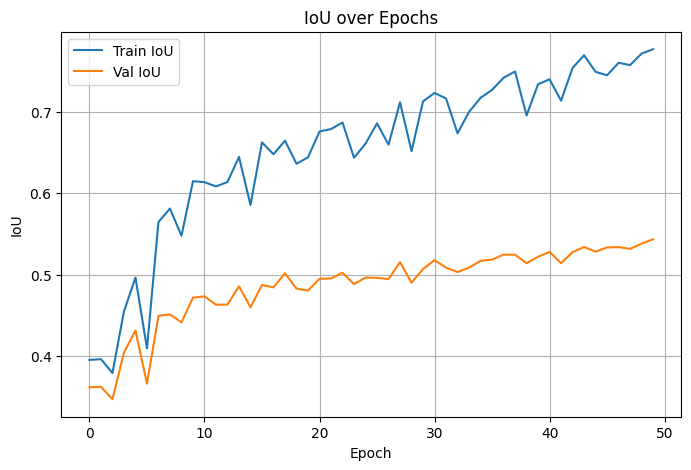

In [ ]:
model = AttentionUNet().to(device)
train_dataset = SegDataset(TRAIN_IMAGES_PATH, TRAIN_MASKS_PATH, transform=shared_transform)
val_dataset = SegDataset(VAL_IMAGES_PATH, VAL_MASKS_PATH, transform=shared_transform)
train_loader = DataLoader(train_dataset, batch_size=8, num_workers=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8,num_workers=8)

train(model, train_loader, val_loader, epochs=50)


In [ ]:
# Save to Drive
import shutil

shutil.copy("BestModelUnet.pth", "/content/drive/MyDrive/CleanExtractedDataset/BestModelUnet.pth")
print(" Model copied to Google Drive!")

 Model copied to Google Drive!


--- Per-Class Metrics (Filtered Classes Only) ---
Class 0: IoU=0.8960, Dice=0.9448, Acc=0.9239
Class 38: IoU=0.2317, Dice=0.2708, Acc=0.9566
Class 75: IoU=0.4949, Dice=0.5696, Acc=0.9332

 Test set metrics saved to: /content/drive/MyDrive/CleanExtractedDataset/test_metrics.csv


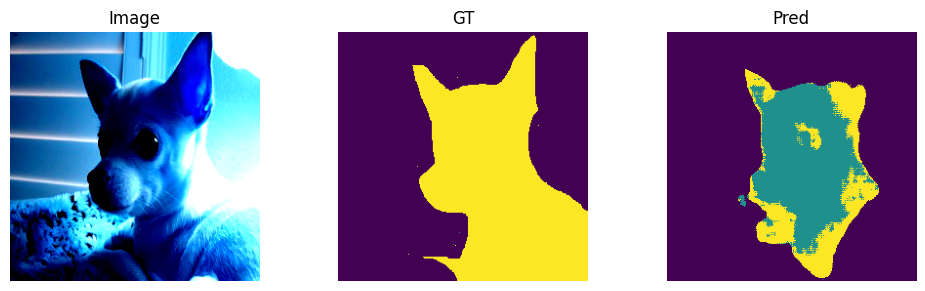

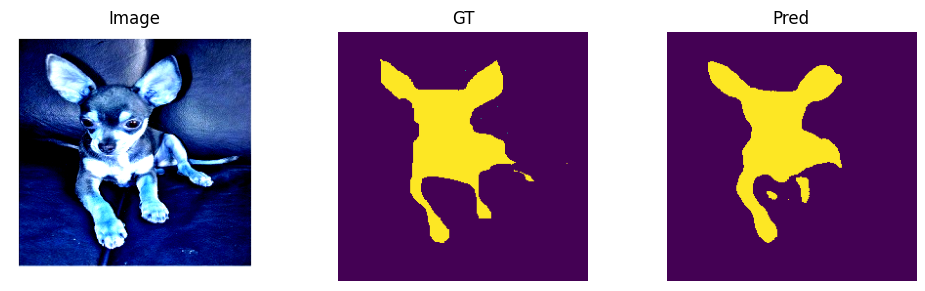

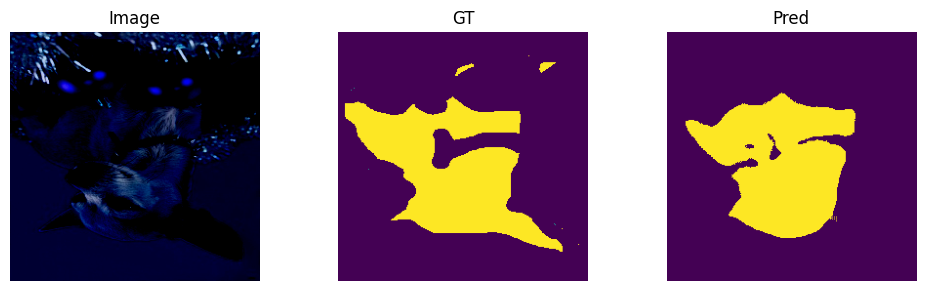

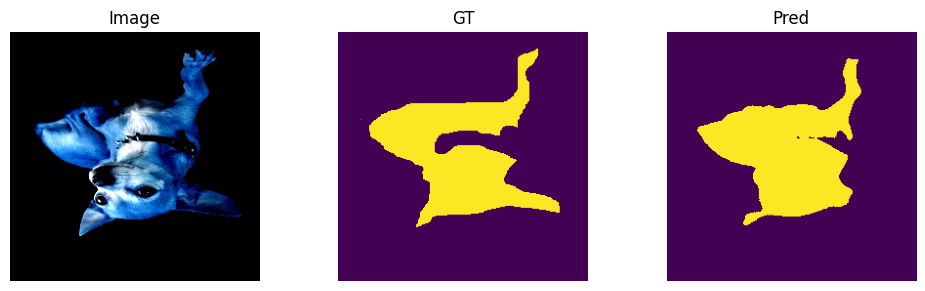

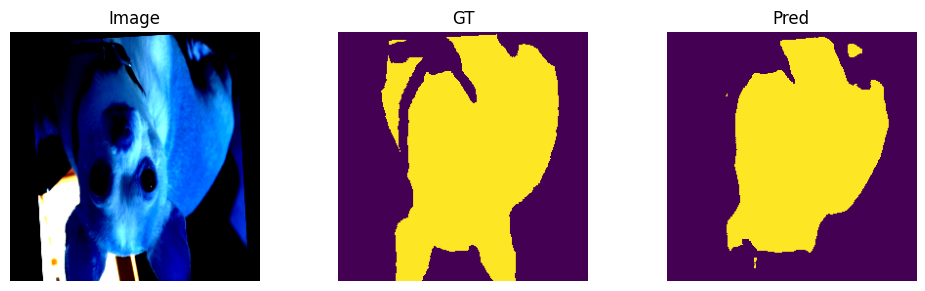

Test predictions visualised.


In [ ]:
# Loads best model
model = AttentionUNet().to(device)
model.load_state_dict(torch.load("/content/drive/MyDrive/CleanExtractedDataset/BestModelUnet.pth"))
model.to(device)

test_dataset = SegDataset(TEST_IMAGES_PATH, TEST_MASKS_PATH, transform=shared_transform)
test_loader = DataLoader(test_dataset, batch_size=16, num_workers=8)
evaluate_test_only(model, test_loader)


# ===============AUTOENCODER PRETRAINING ================

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# ============================ AUTOENCODER SETUP ============================
class EncoderUNet(nn.Module):
    """
    U-Net Style Encoder for Autoencoder Pretraining

    This module defines the encoder part of the autoencoder using a U-Net-like structure.
    It consists of four downsampling blocks and a bottleneck. Each block includes two
    convolutional layers with batch normalization and ReLU activations.

    The encoder captures hierarchical feature maps at multiple spatial resolutions,
    which are returned for skip connections in the decoder.

    Returns:
        List[Tensor]: Feature maps at multiple depths [e1, e2, e3, e4, b]
    """

    def __init__(self):
        super().__init__()
        def block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(),
                nn.Conv2d(out_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU()
            )
        self.enc1 = block(3, 64)
        self.enc2 = block(64, 128)
        self.enc3 = block(128, 256)
        self.enc4 = block(256, 512)
        self.bottleneck = block(512, 1024)
        self.pool = nn.MaxPool2d(2)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b = self.bottleneck(self.pool(e4))
        return [e1, e2, e3, e4, b]

class DecoderAE(nn.Module):
    """
    Decoder for U-Net Style Autoencoder

    This module reconstructs the input image from multi-level encoder features using
    transposed convolutions and skip connections. Each upsampling step is followed by
    a convolutional block that merges encoder features with the upsampled decoder output.

    The final output is passed through a 1×1 convolution to produce a 3-channel reconstructed image.

    Args:
        features (List[Tensor]): Outputs from EncoderUNet [e1, e2, e3, e4, b]

    Returns:
        Tensor: Reconstructed RGB image
    """

    def __init__(self):
        super().__init__()
        def block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(),
                nn.Conv2d(out_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU()
            )
        self.up4 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.dec4 = block(1024, 512)
        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = block(512, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = block(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = block(128, 64)
        self.final = nn.Conv2d(64, 3, kernel_size=1)

    def forward(self, features):
        e1, e2, e3, e4, b = features
        g4 = self.up4(b)
        d4 = self.dec4(torch.cat([g4, e4], dim=1))
        g3 = self.up3(d4)
        d3 = self.dec3(torch.cat([g3, e3], dim=1))
        g2 = self.up2(d3)
        d2 = self.dec2(torch.cat([g2, e2], dim=1))
        g1 = self.up1(d2)
        d1 = self.dec1(torch.cat([g1, e1], dim=1))
        return self.final(d1)

class Autoencoder(nn.Module):
    """
    Full Autoencoder Combining EncoderUNet and DecoderAE

    This class connects the U-Net-based encoder and decoder into a single model
    for image reconstruction. It is used for unsupervised pretraining to encourage
    the encoder to learn meaningful low- and mid-level features.

    Returns:
        Tensor: Reconstructed image
    """
    def __init__(self):
        super().__init__()
        self.encoder = EncoderUNet()
        self.decoder = DecoderAE()

    def forward(self, x):
        return self.decoder(self.encoder(x))

# ============================ TRAINING SETUP ============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
autoencoder = Autoencoder().to(device)
optimizer = torch.optim.Adam(autoencoder.parameters(), lr=1e-4)

vgg = models.vgg16(pretrained=True).features[:16].eval().to(device)
for p in vgg.parameters():
    p.requires_grad = False

# VGG normalization constants
mean = torch.tensor([0.485, 0.456, 0.406], device=device).view(1, 3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225], device=device).view(1, 3, 1, 1)

# Perceptual loss function
def perceptual_loss(input, recon):
    input_scaled = input * std + mean
    recon_scaled = recon * std + mean
    return F.mse_loss(vgg(input_scaled), vgg(recon_scaled))

# ============================ DATASET + DATALOADER ============================

train_dataset = SegDataset(
    img_dir=AUG_IMAGES_PATH,
    mask_dir=AUG_MASKS_PATH,
    transform=shared_transform
)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=8)

# ============================ TRAINING LOOP ============================
for epoch in range(10):
    autoencoder.train()
    total_loss = 0
    for x, _ in tqdm(train_loader):
        x = x.to(device)
        optimizer.zero_grad()
        out = autoencoder(x)
        loss = 0.5 * F.mse_loss(out, x) + 0.5 * perceptual_loss(x, out)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss / len(train_loader):.4f}")

# ============================ SAVE ENCODER ============================
torch.save(autoencoder.encoder.state_dict(), "/content/drive/MyDrive/CleanExtractedDataset/Lastcoder.pth")
print("Encoder saved.")


100%|██████████| 1102/1102 [17:10<00:00,  1.07it/s]


Epoch 1, Loss: 0.2301


100%|██████████| 1102/1102 [01:26<00:00, 12.69it/s]


Epoch 2, Loss: 0.0537


100%|██████████| 1102/1102 [01:26<00:00, 12.69it/s]


...

Epoch 8, Loss: 0.0140


100%|██████████| 1102/1102 [01:26<00:00, 12.69it/s]


Epoch 9, Loss: 0.0126


100%|██████████| 1102/1102 [01:26<00:00, 12.69it/s]


Epoch 10, Loss: 0.0134
Encoder saved.


In [25]:
def load_pretrained_encoder(model, encoder_path):
    print("Loading pretrained encoder weights...")
    encoder_state = torch.load(encoder_path)
    model_dict = model.state_dict()

    # Load only encoder-related weights
    encoder_state = {k: v for k, v in encoder_state.items() if k in model_dict and ("enc" in k or "bottleneck" in k)}
    model_dict.update(encoder_state)
    model.load_state_dict(model_dict)

    # Fine-tune encoder (do not freeze)
    for name, param in model.named_parameters():
        if "enc" in name or "bottleneck" in name:
            param.requires_grad = True

    print("Encoder loaded and set for fine-tuning.")

In [ ]:
model = AttentionUNet().to(device)
load_pretrained_encoder(model, "/content/drive/MyDrive/CleanExtractedDataset/Lastcoder.pth")

val_dataset = SegDataset(VAL_IMAGES_PATH, VAL_MASKS_PATH, transform=shared_transform)
val_loader = DataLoader(val_dataset, batch_size=8, num_workers=8)

train(model, train_loader, val_loader, epochs=75)  # reuse your `train(...)` function

# Save best model
shutil.copy("BestModelUnet.pth", "/content/drive/MyDrive/CleanExtractedDataset/BestModelUnet_Pretrained.pth")

# ================== FINAL MODEL EVALUATION ==================

Loading pretrained encoder weights...
Encoder loaded and set for fine-tuning.
--- Per-Class Metrics (Filtered Classes Only) ---
Class 0: IoU=0.8953, Dice=0.9445, Acc=0.9233
Class 38: IoU=0.2358, Dice=0.2740, Acc=0.9568
Class 75: IoU=0.4893, Dice=0.5654, Acc=0.9331

 Test set metrics saved to: /content/drive/MyDrive/CleanExtractedDataset/FinalAutotest_metrics_pretrained.csv


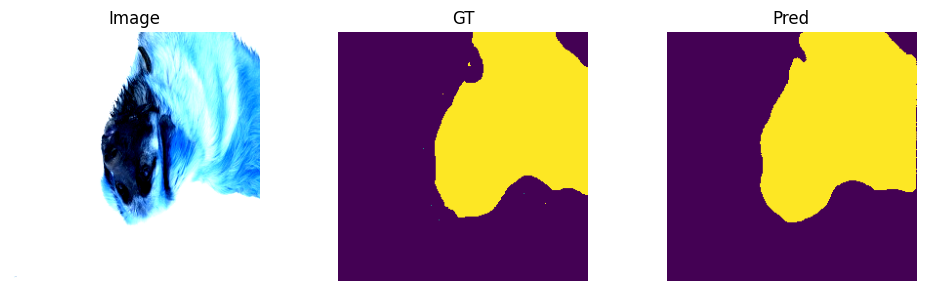

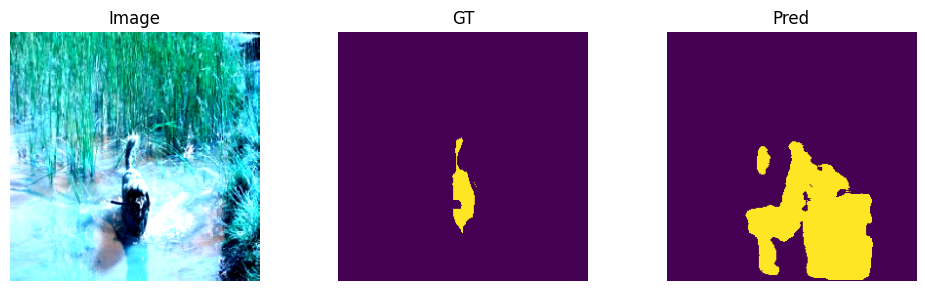

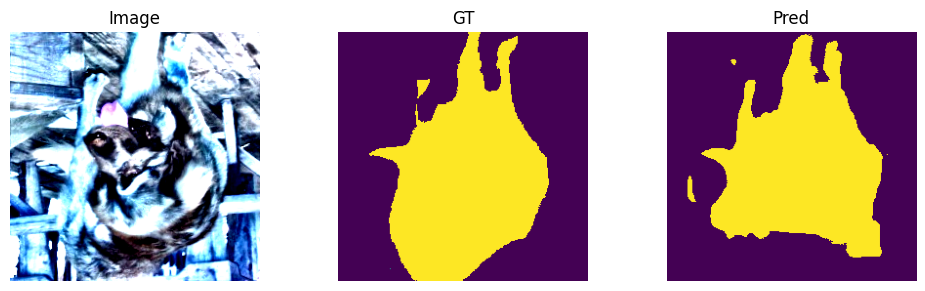

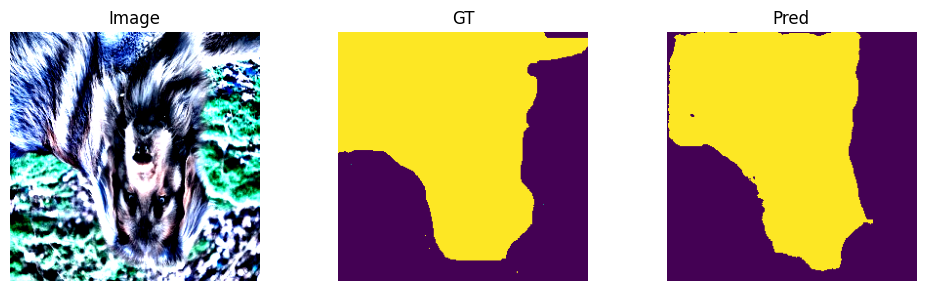

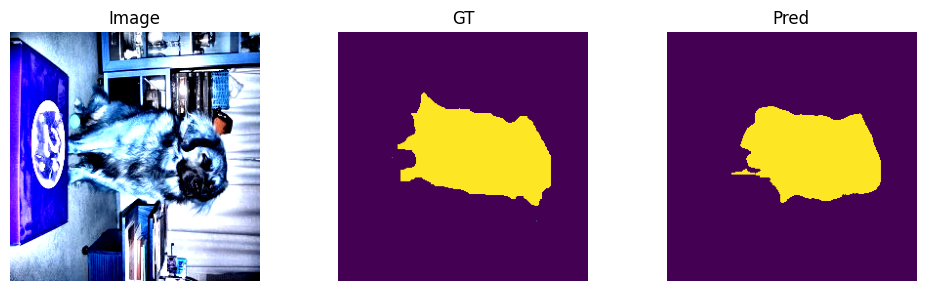

Test predictions visualised.


In [31]:
model = AttentionUNet().to(device)
load_pretrained_encoder(model, "/content/drive/MyDrive/CleanExtractedDataset/LastPretrainedEncoder.pth")
model.load_state_dict(torch.load("/content/drive/MyDrive/CleanExtractedDataset/BestModelUnet_Pretrained.pth"))
model.to(device)

test_dataset = SegDataset(TEST_IMAGES_PATH, TEST_MASKS_PATH, transform=shared_transform)
test_loader = DataLoader(test_dataset, batch_size=16, num_workers=8)

evaluate_test_only(model, test_loader, out_csv="/content/drive/MyDrive/CleanExtractedDataset/FinalAutotest_metrics_pretrained.csv")


# =========== FINAL MODEL Visualisations For the Report ===============


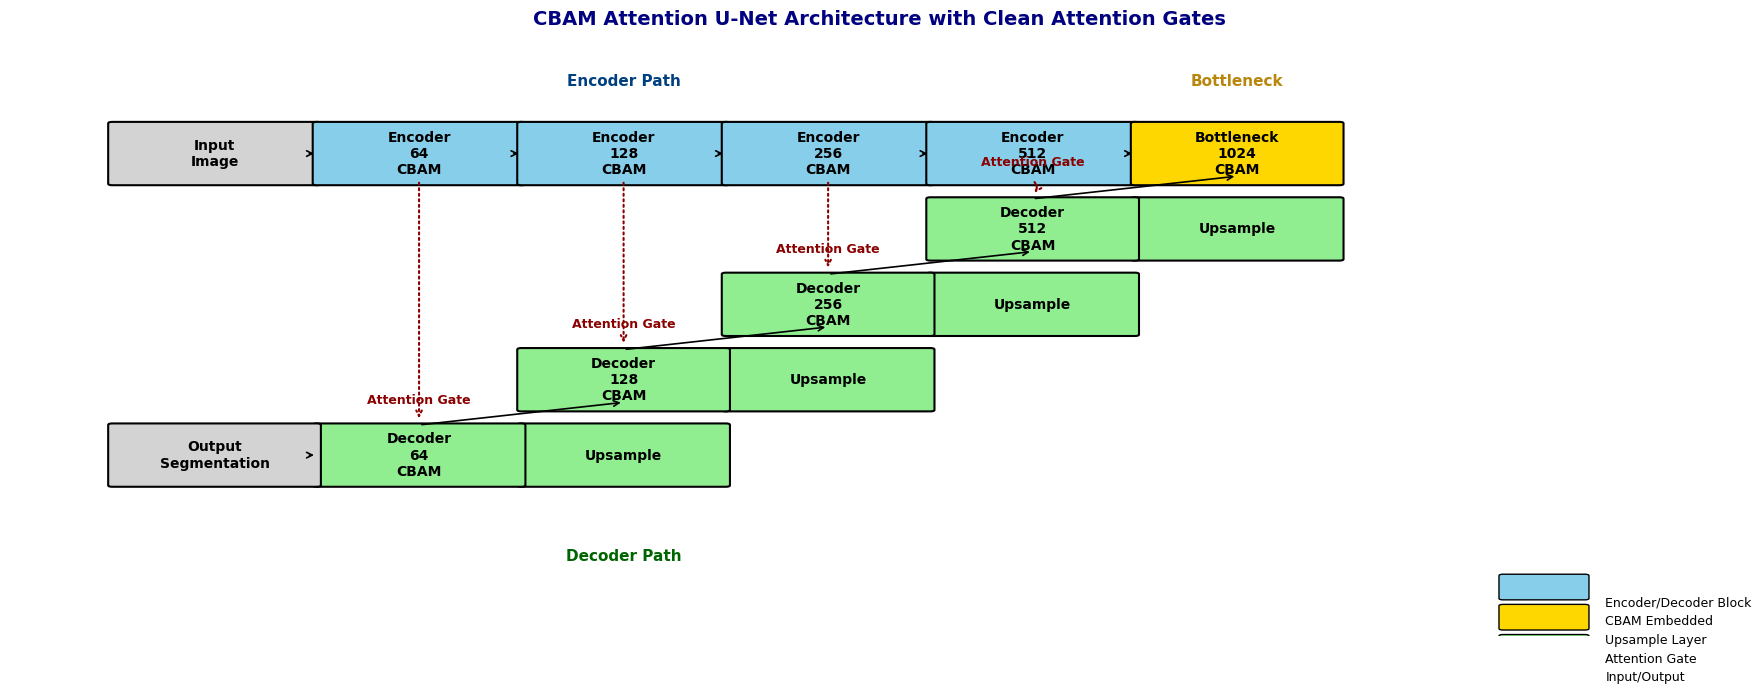

In [42]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(18, 7))

blocks = [
    # Encoder
    ("Input\nImage", 0, 3, '#D3D3D3'),
    ("Encoder\n64\nCBAM", 1, 3, '#87CEEB'),
    ("Encoder\n128\nCBAM", 2, 3, '#87CEEB'),
    ("Encoder\n256\nCBAM", 3, 3, '#87CEEB'),
    ("Encoder\n512\nCBAM", 4, 3, '#87CEEB'),
    # Bottleneck
    ("Bottleneck\n1024\nCBAM", 5, 3, '#FFD700'),
    # Decoder
    ("Upsample", 5, 2, '#90EE90'),
    ("Decoder\n512\nCBAM", 4, 2, '#90EE90'),
    ("Upsample", 4, 1, '#90EE90'),
    ("Decoder\n256\nCBAM", 3, 1, '#90EE90'),
    ("Upsample", 3, 0, '#90EE90'),
    ("Decoder\n128\nCBAM", 2, 0, '#90EE90'),
    ("Upsample", 2, -1, '#90EE90'),
    ("Decoder\n64\nCBAM", 1, -1, '#90EE90'),
    ("Output\nSegmentation", 0, -1, '#D3D3D3')
]

# Draws blocks
for label, x, y, color in blocks:
    rect = patches.FancyBboxPatch((x, y), 1, 0.8,
                                   boxstyle="round,pad=0.02", edgecolor='black', facecolor=color, linewidth=1.5)
    ax.add_patch(rect)
    ax.text(x + 0.5, y + 0.4, label, ha="center", va="center", fontsize=10, fontweight='bold')

# Encoder arrows
for i in range(0, 5):
    ax.annotate("", xy=(i+1, 3.4), xytext=(i+0.95, 3.4), arrowprops=dict(arrowstyle="->", lw=1.2))

# Decoder flow arrows
decoder_arrows = [(5, 4, 2), (4, 3, 1), (3, 2, 0), (2, 1, -1)]
for up_x, dec_x, y in decoder_arrows:
    ax.annotate("", xy=(up_x + 0.5, y + 1.1), xytext=(dec_x + 0.5, y + 0.8),
                arrowprops=dict(arrowstyle="->", lw=1.2))

# Skips connections using Bezier curve style for clarity
for enc_x, dec_x, y in [(4, 4, 2), (3, 3, 1), (2, 2, 0), (1, 1, -1)]:
    style = "arc3,rad=-0.5" if enc_x == 4 else "arc3,rad=0.0"
    ax.annotate("",
                xy=(dec_x + 0.5, y + 0.85), xytext=(enc_x + 0.5, 3.05),
                arrowprops=dict(arrowstyle="->", linestyle="dotted", lw=1.5, color='darkred',
                                connectionstyle=style))
    ax.text(enc_x + 0.5, 3.2 if enc_x == 4 else y + 1.05, "Attention Gate",
            ha="center", va="bottom", fontsize=9, color='darkred', fontweight='bold')

# Output arrow
ax.annotate("", xy=(1, -0.6), xytext=(0.95, -0.6), arrowprops=dict(arrowstyle="->", lw=1.2))

# Section headers
ax.text(2.5, 4.3, "Encoder Path", fontsize=11, fontweight='bold', ha="center", color='#004080')
ax.text(5.5, 4.3, "Bottleneck", fontsize=11, fontweight='bold', ha="center", color='#B8860B')
ax.text(2.5, -2.0, "Decoder Path", fontsize=11, fontweight='bold', ha="center", color='#006400')

# Legend
legend_items = [
    ("Encoder/Decoder Block", '#87CEEB'),
    ("CBAM Embedded", '#FFD700'),
    ("Upsample Layer", '#90EE90'),
    ("Attention Gate", 'darkred'),
    ("Input/Output", '#D3D3D3')
]
legend_y = -2.5
for i, (label, color) in enumerate(legend_items):
    rect = patches.FancyBboxPatch((6.8, legend_y - i * 0.4), 0.4, 0.3,
                                  boxstyle="round,pad=0.02", edgecolor='black', facecolor=color)
    ax.add_patch(rect)
    ax.text(7.3, legend_y - i * 0.25 - 0.05, label, va='center', fontsize=9)

# Final layout settings
ax.set_xlim(-0.5, 8)
ax.set_ylim(-3, 5)
ax.axis("off")
plt.title("CBAM Attention U-Net Architecture with Clean Attention Gates", fontsize=14, fontweight='bold', color='navy')
plt.tight_layout()
plt.show()


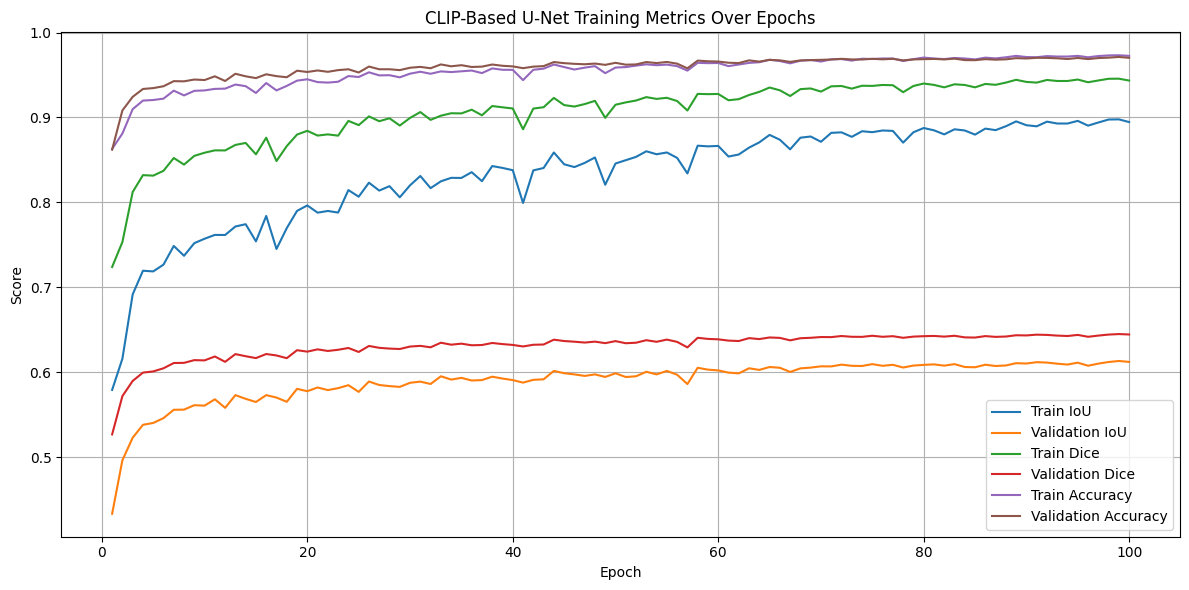

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Loads the training log
clip_log_path = "/content/drive/MyDrive/last/INCREASECBAMAttentionUnetTraining_logUpd_Clip_Promptcsv (1).csv"
clip_log = pd.read_csv(clip_log_path)

# Plots metrics
plt.figure(figsize=(12, 6))
plt.plot(clip_log['Epoch'], clip_log['Train IoU'], label='Train IoU')
plt.plot(clip_log['Epoch'], clip_log['Val IoU'], label='Validation IoU')
plt.plot(clip_log['Epoch'], clip_log['Train Dice'], label='Train Dice')
plt.plot(clip_log['Epoch'], clip_log['Val Dice'], label='Validation Dice')
plt.plot(clip_log['Epoch'], clip_log['Train Acc'], label='Train Accuracy')
plt.plot(clip_log['Epoch'], clip_log['Val Acc'], label='Validation Accuracy')

plt.title('CLIP-Based U-Net Training Metrics Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.tight_layout()

# Saves to Google Drive (make sure this folder exists and is mounted)
save_path = "/content/drive/MyDrive/last/CLIP_PROMT_Training_Metrics.png"
plt.savefig(save_path)

plt.show()
